<a href="https://colab.research.google.com/github/JaviSantosM/Economia3/blob/main/Data_Analyst_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Analyst Assignment

## Data Challenge

Sales leadership has tasked you with analyzing the data to discover how employee training
impacts sales performance and effectiveness. The goal is to identify patterns and provide
actionable recommendations that drive sales growth and improve team performance by
answering the following questions.
Questions
1. What is the training completion rate for each course by segments (SVP Leader/Region),
factoring in the following caveats? Training is required for all employees except:
* Employees currently on leave are exempt from the training requirement.
* 'Sell More Suite SKU' course is not required for employees within the 'Advocacy'
cost center family.
* “Suite/Automation Technical Lab” and “Advanced Suite Bots Lab Course”
courses are required only for employees in the 'PreSales' and 'Services' cost
center family.

2. How would you analyze the performance of an account executive? Is there a difference
between those who have completed training and those who have not? How would you
segment the data and present your findings to senior stakeholders?
* Hint: Look at this from an overall employee perspective who has completed any
training vs. those who have not completed any training. Any training would count,

rather than distinguishing which specific courses were completed, as they all
contribute to one Suite product.

3. Any other interesting insights that you can see in the data? Any data quality issues with
the data? Any challenges with analyzing the data? What additional data do you think
would be useful for further analyzing the existing datasets?



---

## Data Dictionary

### Table 1 : Employee Information

This table maintains critical employment details for organization members, including
identification, job titles, management hierarchies, tenure, and work region

* **Employee_ID:** Unique identifier for each employee.
* **SVP Leader:** Leader overseeing the employee.
* **Business Title:** Official job title of the employee.
* **Cost Center:** Identifier for the employee's department or unit for cost tracking.
* **Cost Center Family:** Group of related cost centers for financial reporting.
* **Length of Service:** Total time the employee has worked at the company.
* **Leave Status:** Indication of whether the employee is on leave.
* **Is People Manager?:** Indicates if the employee oversees other staff.
* **Region:** Geographic area where the employee works.
* **Manager IC Helper:** Additional data supporting managerial status.
* **IC:** Individual Contributor

### Table 2: Completed Trainings
This table records the professional development activities of employees by linking completed
training programs to their unique identifiers
* **Employee_ID:** Unique identifier linked to an employee who completed the training.
* **Training Name:** Name of the training program or course that the employee completed.

### Table 3: Performance Data
This table includes the sales and revenue generation activities of employees by cataloguing
opportunities, their progression, and financial outcomes. It captures granular data on sales
stage milestones, product-related charges, and revenue figures, all linked by employee and
opportunity identifiers, making it a vital asset for analyzing sales performance and compensation
metrics.

* **Employee_ID:** Unique identifier for the employee associated.
* **Opportunity ID:** Unique identifier for the sales opportunity.
* **Type:** The category or classification of the opportunity.
* Expansion is for existing business

* **Stage 2+ Date:** The date when the opportunity reached or surpassed stage 2 in the
sales process.
* **Stage:** Current stage of the opportunity in the sales pipeline.
 * 02 - Discovery: Initial stage where potential needs and opportunities are
identified with the client.
 * 03 - Solution Review: Potential solutions are presented and reviewed with the
client.
 * 04 - Solution Validation: Client feedback is incorporated, and solutions are
refined and validated.
 * 05 - Contracting / Verba: Terms are negotiated and a verbal agreement may be
reached.
 * 06 - Signed/07 - Closed: Formal agreement is executed with signatures from all
parties. Signed and Closed are counted as finalized
* **Close Date:** The date when the opportunity was closed.
* **Product Rate Plan Charge:** The charge associated with the product's rate plan.
* **Product Name:** The name of the product related to the opportunity.
* **Add-On ARR (converted):** The value of the additional ARR from add-ons,
* **Total Commissionable ARR (converted):** The total annual recurring revenue that is
eligible for commission

#Codigo

In [10]:
import pandas as pd

file = "Assignment_2.xlsx"

employees = pd.read_excel("/content/Assignment_2.xlsx", sheet_name='Employee_Data')
trainings = pd.read_excel("/content/Assignment_2.xlsx", sheet_name='Completed_Trainings')
performance = pd.read_excel("/content/Assignment_2.xlsx", sheet_name='Performance Data')

In [11]:
employees.head()

,Employee_ID,SVP Leader,Business Title,Cost Center,Cost Center Family,Length of service,Leave Status,is People Manager?,Region,Manager IC Helper
0,1,Leader 1,Senior Commercial Account Executive,532 Commercial AE,Commercial,20,Active,False,EMEA,IC
1,2,Leader 1,Senior Commercial Account Executive,532 Commercial AE,Commercial,13,Active,False,EMEA,IC
2,3,Leader 1,Senior Commercial Account Executive,552 Mid-Market AE,Mid-Market,44,Active,False,EMEA,IC
3,4,Leader 2,Enterprise Corporate Account Executive,508 LATAM Enterprise AE,Enterprise,9,Active,False,LATAM,IC
4,5,Leader 1,Senior Commercial Account Executive,532 Commercial AE,Commercial,15,Active,False,EMEA,IC


In [12]:
trainings.head()

,Employee_ID,Training_Completed
0,2.0,Sell More Suite SKU
1,5.0,Sell More Suite SKU
2,9.0,Sell More Suite SKU
3,10.0,Sell More Suite SKU
4,12.0,Sell More Suite SKU


In [13]:
performance.head()

,Employee_ID,Opportunity ID,Type,Stage 2+ Date,Stage,Close Date,Product Rate Plan Charge,Product Name,Add-On ARR (converted) Currency,Add-On ARR (converted),Total Commissionable ARR (converted) Currency,Total Commissionable ARR (converted)
0,963.0,10000,New Business,2016-10-16,03 - Solution Review,2018-06-03,Suite Subscription,Support: Addons,USD,25771,USD,225073
1,435.0,10005,Expansion,2017-12-14,02 - Discovery,2018-03-02,Suite Subscription,Support: Addons,USD,6861,USD,4561
2,33.0,10010,Expansion,2017-12-17,02 - Discovery,2018-06-09,Suite Subscription,Support: Addons,USD,21198,USD,11215
3,1634.0,10015,Expansion,2017-12-15,02 - Discovery,2018-03-30,Suite Subscription,Support: Addons,USD,47413,USD,46811
4,1998.0,10020,New Business,2017-12-22,02 - Discovery,2018-02-13,Suite Subscription,Support: Addons,USD,3973,USD,6700


In [16]:
trainings = trainings.rename(columns={"Training_Completed": "Training Name"})

In [17]:
df = employees.merge(trainings, on="Employee_ID", how="left")
df.head()

,Employee_ID,SVP Leader,Business Title,Cost Center,Cost Center Family,Length of service,Leave Status,is People Manager?,Region,Manager IC Helper,Training Name
0,1,Leader 1,Senior Commercial Account Executive,532 Commercial AE,Commercial,20,Active,False,EMEA,IC,Suite/Automation Technical Lab
1,2,Leader 1,Senior Commercial Account Executive,532 Commercial AE,Commercial,13,Active,False,EMEA,IC,Sell More Suite SKU
2,3,Leader 1,Senior Commercial Account Executive,552 Mid-Market AE,Mid-Market,44,Active,False,EMEA,IC,NaN
3,4,Leader 2,Enterprise Corporate Account Executive,508 LATAM Enterprise AE,Enterprise,9,Active,False,LATAM,IC,NaN
4,5,Leader 1,Senior Commercial Account Executive,532 Commercial AE,Commercial,15,Active,False,EMEA,IC,Sell More Suite SKU


In [19]:
df["completed_training"] = df["Training Name"].notna()
df.head()

,Employee_ID,SVP Leader,Business Title,Cost Center,Cost Center Family,Length of service,Leave Status,is People Manager?,Region,Manager IC Helper,Training Name,completed_training
0,1,Leader 1,Senior Commercial Account Executive,532 Commercial AE,Commercial,20,Active,False,EMEA,IC,Suite/Automation Technical Lab,True
1,2,Leader 1,Senior Commercial Account Executive,532 Commercial AE,Commercial,13,Active,False,EMEA,IC,Sell More Suite SKU,True
2,3,Leader 1,Senior Commercial Account Executive,552 Mid-Market AE,Mid-Market,44,Active,False,EMEA,IC,NaN,False
3,4,Leader 2,Enterprise Corporate Account Executive,508 LATAM Enterprise AE,Enterprise,9,Active,False,LATAM,IC,NaN,False
4,5,Leader 1,Senior Commercial Account Executive,532 Commercial AE,Commercial,15,Active,False,EMEA,IC,Sell More Suite SKU,True


In [20]:
df["required_training"] = True

In [21]:
df.loc[df["Leave Status"] == "On Leave", "required_training"] = False

In [22]:
df.loc[
    (df["Training Name"] == "Sell More Suite SKU") &
    (df["Cost Center Family"] == "Advocacy"),
    "required_training"
] = False

In [23]:
df.loc[
    (df["Training Name"].isin([
        "Suite/Automation Technical Lab",
        "Advanced Suite Bots Lab Course"
    ])) &
    (~df["Cost Center Family"].isin(["PreSales", "Services"])),
    "required_training"
] = False

In [24]:
completion = df[df["required_training"] == True].groupby(
    ["SVP Leader", "Region"]
)["completed_training"].mean().reset_index()


#Grafica de Cursos completados por Lider y Region

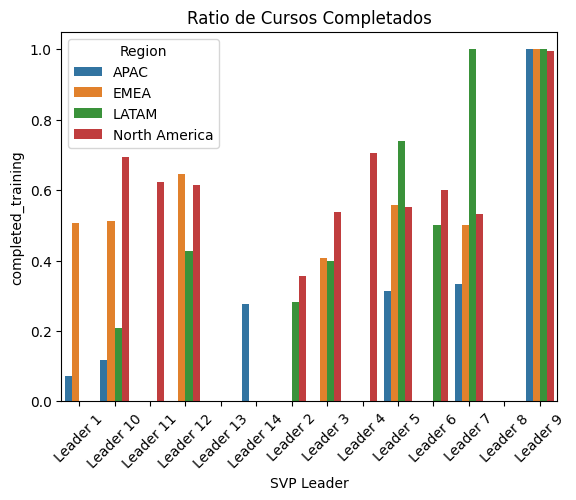

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=completion, x="SVP Leader", y="completed_training", hue="Region")
plt.xticks(rotation=45)
plt.title("Ratio de Cursos Completados")
plt.show()

In [26]:
training_flag = trainings.groupby("Employee_ID").size().reset_index(name="count")
training_flag["took_training"] = True

In [27]:
employees = employees.merge(
    training_flag[["Employee_ID", "took_training"]],
    on="Employee_ID",
    how="left"
)

employees["took_training"] = employees["took_training"].fillna(False)

/tmp/ipykernel_4003/648778822.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  employees["took_training"] = employees["took_training"].fillna(False)


In [28]:
perf_summary = performance.groupby("Employee_ID").agg({
    "Total Commissionable ARR (converted)": "sum",
    "Opportunity ID": "count"
}).reset_index()

perf_summary.columns = ["Employee_ID", "Total_ARR", "Num_Deals"]

In [29]:
analysis = employees.merge(perf_summary, on="Employee_ID", how="left")

In [30]:
analysis.groupby("took_training")[["Total_ARR", "Num_Deals"]].mean()

,Total_ARR,Num_Deals
took_training,,
False,155279.390977,2.000000
True,236074.714286,2.201299


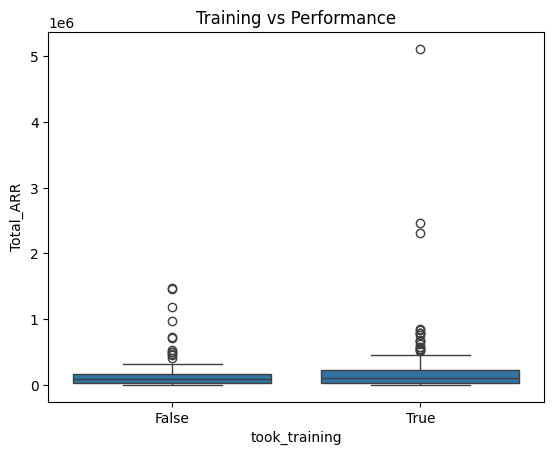

In [31]:
sns.boxplot(data=analysis, x="took_training", y="Total_ARR")
plt.title("Training vs Performance")
plt.show()

#Resultados


##Ratio de cursos Completados

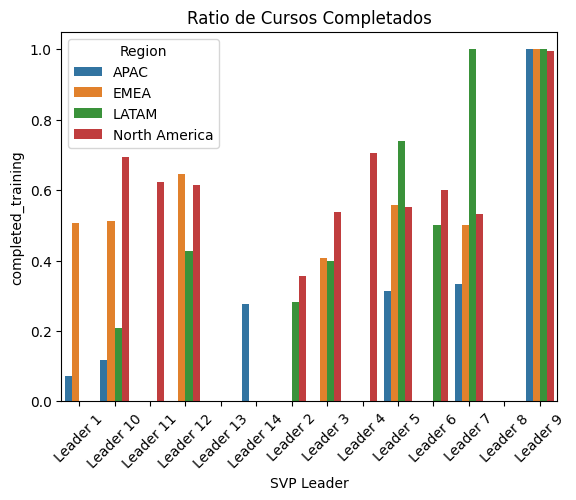

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=completion, x="SVP Leader", y="completed_training", hue="Region")
plt.xticks(rotation=45)
plt.title("Ratio de Cursos Completados")
plt.show()

###Respuesta a la pregunta 1
En esta tabla podemos ver que tanto porcentaje de empleados ha completado los cursos, de acuerdo al lider y a la region

##Diferencia de ventas entre personas con cursos y sin ellos

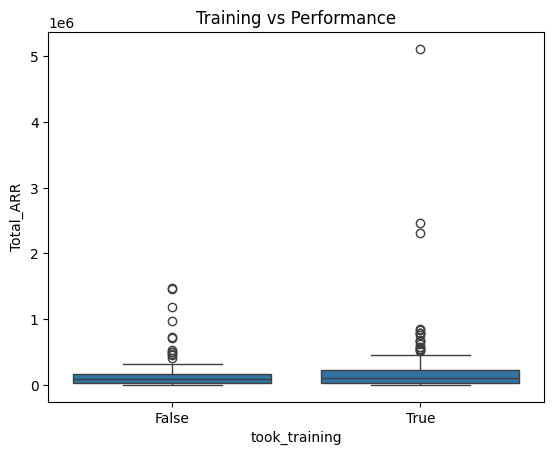

In [34]:
sns.boxplot(data=analysis, x="took_training", y="Total_ARR")
plt.title("Cursos vs No cursos")
plt.show()

In [35]:
analysis.groupby("took_training")[["Total_ARR", "Num_Deals"]].mean()

,Total_ARR,Num_Deals
took_training,,
False,155279.390977,2.000000
True,236074.714286,2.201299


###Respuesta a la pregunta 2
Vamos a medir de forma general, poniendo la información de las personas sin cursos contra la información de las que si han tomado algun curso, para esto mostraremos una grafica de caja de las ganancias. Para medir su trabajo podríamos pensar en que se debe medir cuantos tratos han llegado a cerrar, pero por el análisis hecho, esto no es suficiente ya que la diferencia entre las personas que tomaron cursos y las que no tomaron es muy pequeña, por lo que tomamos como siguiente medida las ganancias hechas, que por lo que podemos notar, las personas con cursos llegan a tener unas ganancias generalmente superiores que las personas que no han tomado ningún curso

###Respuesta a la pregunta 3

Insights: Sería interesante analizar los datos solo por región, pues en la gráfica mostrada del ratio de completación, algunas regiones parecen no depender tanto del líder. Otra cosa a analizar sería si en realidad los cursos tomados por los empleados son los que hacen que suba su valor de ventas

Problemas: Falta de la existencia de una fecha para los cursos, sin esta no podemos saber si los cursos en realidad generaron una mejoria en los empleados